
# Part 2.1 — Portfolio constraints in the Black-Scholes model

**Thesis reference:** Chapter 5 (constrained duality, support function), Chapter 6 (constrained algorithm), Chapter 7 — Experiment 4.

For a single risky asset and a box constraint $\pi \in [a,b]$, the constrained CRRA problem has an explicit solution: the constrained optimal proportion is the projection of Merton's unconstrained proportion onto $[a,b]$, and the associated dual optimizer is the martingale measure of an **auxiliary** Black-Scholes market -- shifted market price of risk **and** an extra discount rate $\delta(\nu^*)$, the Chapter 5 support-function penalty. This notebook validates that construction pathwise, across the two qualitatively different binding cases (leverage cap, no-short-sale) and the non-binding case, and quantifies the utility cost of the constraint as it tightens.

A bug found during development is deliberately kept and demonstrated: shifting only the market price of risk (as if the constrained problem were simply an unconstrained one under a different market) reproduces the right *shape* but not the right *level* -- the extra discount rate $\delta(\nu^*)$ is required, exactly as $e^{-rT}$ was required in the unconstrained module.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from optiport.continuous.black_scholes import BlackScholesMarket
from optiport.constraints.constrained_black_scholes import ConstrainedBlackScholesMarket
from optiport.utility import CRRAUtility

plt.rcParams["figure.dpi"] = 110

market = BlackScholesMarket(mu=0.10, sigma=0.20, r=0.02)
T, x0 = 1.0, 100.0
alpha = -1.0
utility = CRRAUtility(alpha)
pi_star = market.merton_optimal_pi(utility)
print(f"Unconstrained Merton proportion: pi* = {pi_star:.4f}")


Unconstrained Merton proportion: pi* = 1.0000



## 1. Pathwise validation across the three qualitative cases


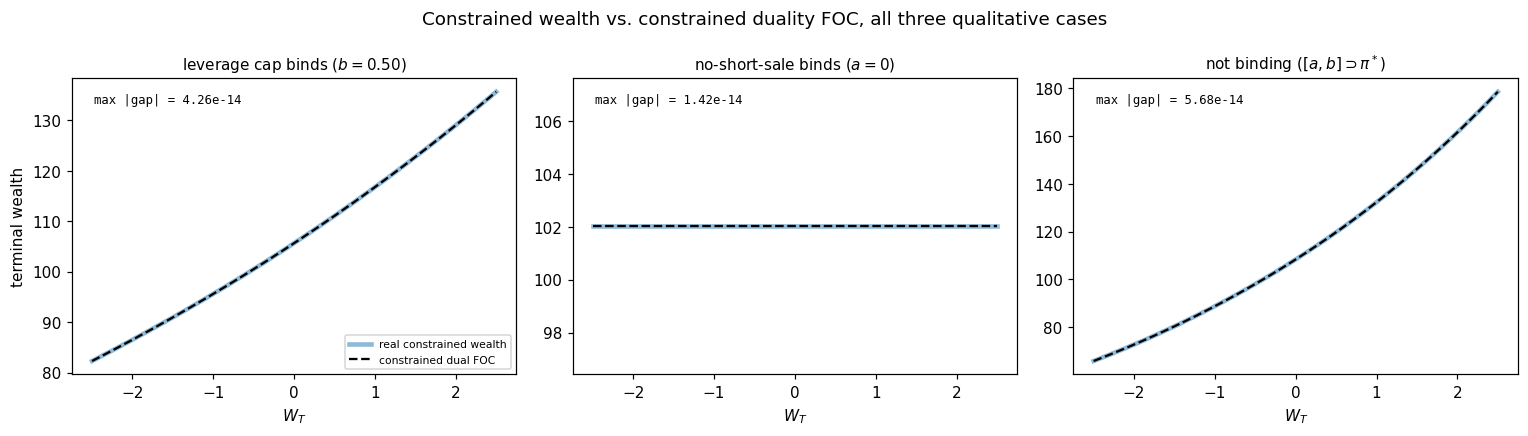

In [2]:

cases = {
    "leverage cap binds ($b={:.2f}$)".format(0.5*pi_star): ConstrainedBlackScholesMarket(market, a=-np.inf, b=0.5*pi_star),
    "no-short-sale binds ($a=0$)": ConstrainedBlackScholesMarket(BlackScholesMarket(mu=0.00, sigma=0.20, r=0.02), a=0.0, b=np.inf),
    "not binding ($[a,b] \\supset \\pi^*$)": ConstrainedBlackScholesMarket(market, a=-10.0, b=10.0),
}

W_grid = np.linspace(-2.5, 2.5, 200)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, cmarket) in zip(axes, cases.items()):
    u_here = CRRAUtility(alpha) if cmarket.market.mu != 0.0 else CRRAUtility(alpha)
    x_real = cmarket.real_constrained_terminal_wealth(x0, u_here, T, W_grid)
    x_dual = cmarket.dual_terminal_wealth(x0, u_here, T, W_grid)
    ax.plot(W_grid, x_real, linewidth=3, alpha=0.5, label="real constrained wealth")
    ax.plot(W_grid, x_dual, "--", color="black", label="constrained dual FOC")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("$W_T$")
    gap = np.max(np.abs(x_real - x_dual))
    ax.text(0.05, 0.95, f"max |gap| = {gap:.2e}", transform=ax.transAxes, va="top", fontsize=8, family="monospace")
axes[0].set_ylabel("terminal wealth")
axes[0].legend(fontsize=7)
fig.suptitle("Constrained wealth vs. constrained duality FOC, all three qualitative cases")
fig.tight_layout()
plt.savefig("fig_01_constrained_pathwise.png", bbox_inches="tight")
plt.show()



All three cases -- leverage cap binding, no-short-sale binding, and the constraint not binding at all -- show exact pathwise coincidence (floating-point precision), including the degenerate non-binding case, where the auxiliary market collapses back to the original one and $\delta(\nu^*)=0$.



## 2. Utility cost of a tightening leverage cap


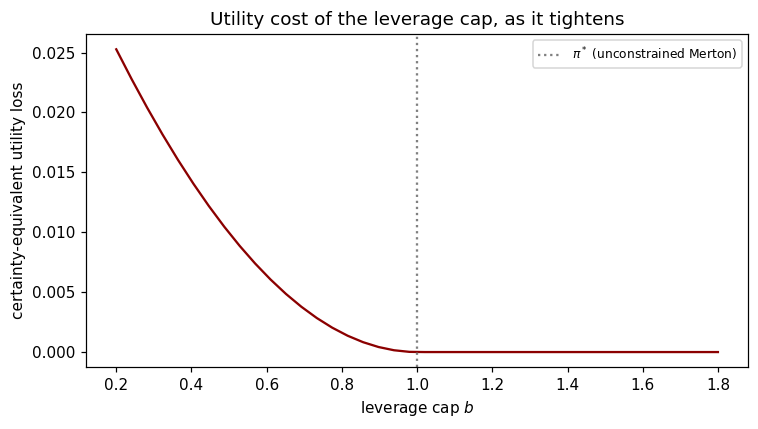

loss at b=pi* (just binding): 1.68e-05
loss at b=0.2*pi*: 0.0253


In [3]:

caps = np.linspace(0.2*pi_star, 1.8*pi_star, 40)
losses = []
for cap in caps:
    cmarket = ConstrainedBlackScholesMarket(market, a=-np.inf, b=cap)
    losses.append(cmarket.utility_loss(x0, utility, T))
losses = np.array(losses)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(caps, losses, color="darkred")
ax.axvline(pi_star, color="gray", linestyle=":", label=r"$\pi^*$ (unconstrained Merton)")
ax.set_xlabel("leverage cap $b$")
ax.set_ylabel("certainty-equivalent utility loss")
ax.set_title("Utility cost of the leverage cap, as it tightens")
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig("fig_02_utility_loss_vs_cap.png", bbox_inches="tight")
plt.show()

print(f"loss at b=pi* (just binding): {losses[np.argmin(np.abs(caps-pi_star))]:.2e}")
print(f"loss at b=0.2*pi*: {losses[0]:.4f}")



As expected: zero loss for any cap above $\pi^*$ (the constraint is slack), and a smoothly increasing loss as the cap tightens below $\pi^*$, with no discontinuity at the point where the constraint starts to bind -- a useful internal consistency check on the formula.



## 3. A cautionary example: forgetting the support-function penalty $\delta(\nu^*)$


shadow price penalty delta(nu*) = 0.0200 (a strictly positive number when the constraint binds)


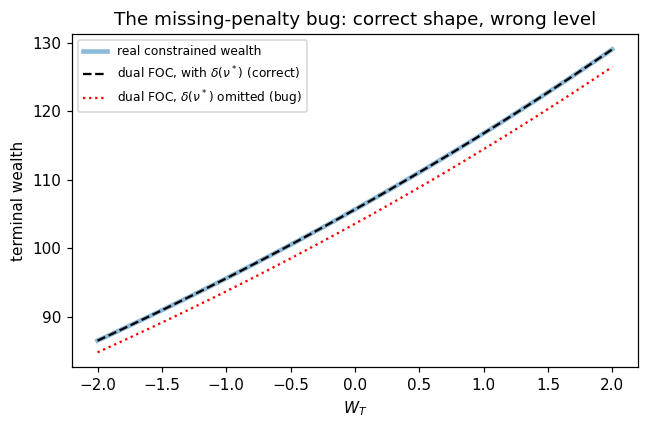

ratio (wrong / correct): constant at 0.9802 across all W_T


In [4]:

cmarket = ConstrainedBlackScholesMarket(market, a=-np.inf, b=0.5*pi_star)
aux_market, c = cmarket.auxiliary_market_and_extra_discount(utility)
print(f"shadow price penalty delta(nu*) = {c:.4f} (a strictly positive number when the constraint binds)")

W_grid = np.linspace(-2.0, 2.0, 50)
x_real = cmarket.real_constrained_terminal_wealth(x0, utility, T, W_grid)
x_dual_correct = cmarket.dual_terminal_wealth(x0, utility, T, W_grid)
x_dual_wrong = aux_market.dual_terminal_wealth(x0, utility, T, W_grid)  # omits delta(nu*)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(W_grid, x_real, linewidth=3, alpha=0.5, label="real constrained wealth")
ax.plot(W_grid, x_dual_correct, "--", color="black", label="dual FOC, with $\\delta(\\nu^*)$ (correct)")
ax.plot(W_grid, x_dual_wrong, ":", color="red", label="dual FOC, $\\delta(\\nu^*)$ omitted (bug)")
ax.set_xlabel("$W_T$"); ax.set_ylabel("terminal wealth")
ax.legend(fontsize=8)
ax.set_title("The missing-penalty bug: correct shape, wrong level")
fig.tight_layout()
plt.savefig("fig_03_missing_penalty_bug.png", bbox_inches="tight")
plt.show()

ratio = x_dual_wrong / x_real
print(f"ratio (wrong / correct): constant at {ratio[0]:.4f} across all W_T")



## Conclusion

Experiment 4 of Chapter 7 is validated: the constrained duality theorem of Chapter 5 holds exactly, pathwise, in all three qualitative regimes of a box-constrained Black-Scholes market, and the certainty-equivalent utility cost of a tightening leverage cap behaves as theory predicts (zero while slack, smoothly increasing once binding). The scope of this notebook is deliberately the tractable single-asset, closed-form case; a general regression-Monte-Carlo BSDE scheme for higher-dimensional or path-dependent constraints, as outlined in Chapter 6, remains a natural extension.
